# Brawler-pick recommender v1

Phase 6 work. Companion to `docs/recommender-v1.md` and `src/brawlstar_agent/recommender/`.

This notebook is **re-runnable as data accumulates**. Same code, same cell outputs, but
with more (train, test) pairs available for temporal CV as months pass.

Hard prereq: a fresh DB. If `data/brawlstars.db` is stale:

```bash
rsync -avz --progress brawl:brawlstar-agent/data/brawlstars.db data/brawlstars.db
```

In [1]:
%load_ext autoreload
%autoreload 2

import sys, time
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(REPO / 'src') not in sys.path:
    sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from brawlstar_agent.recommender import (
    CLEAN_CUTOFF_ISO, load_clean_battles, load_brawler_names, split_random,
)
from brawlstar_agent.recommender.baselines import (
    GlobalWilsonBaseline, ModeWilsonBaseline, ModeMapWilsonBaseline,
)
from brawlstar_agent.recommender.team_model import (
    LogRegTeamModel, LGBMTeamModel, evaluate,
)
from brawlstar_agent.recommender.cv import make_temporal_folds, evaluate_models_on_folds
from brawlstar_agent.recommender.inference import (
    rank_brawlers_for_map, complete_team, last_pick,
)

names = load_brawler_names()
ids = {v: k for k, v in names.items()}
print(f'Resolved {len(names)} brawlers')

Resolved 103 brawlers


## 1. Load clean window data

Rows (both perspectives): 105,260   battles: 52,630
Time range: 2026-05-03T01:00:16+00:00  to  2026-05-05T02:55:40+00:00


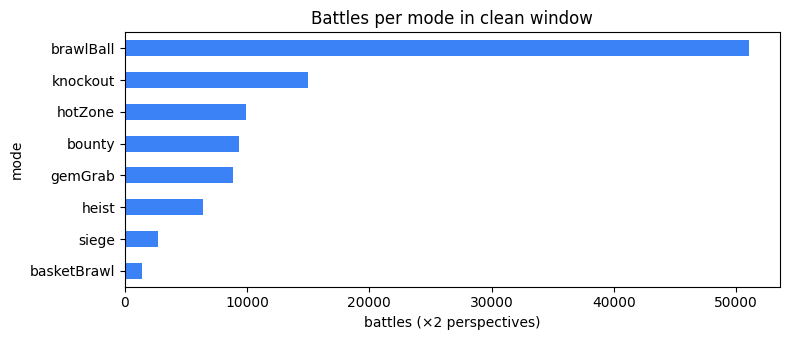

In [2]:
df = load_clean_battles().dropna(subset=['mode', 'map', 'battle_type'])
print(f'Rows (both perspectives): {len(df):,}   battles: {df["battle_id"].nunique():,}')
print(f'Time range: {df["battle_time_iso"].min()}  to  {df["battle_time_iso"].max()}')
df['mode'].value_counts().head(8).plot(kind='barh', figsize=(8,3.5), color='#3b82f6')
plt.title('Battles per mode in clean window')
plt.xlabel('battles (×2 perspectives)')
plt.gca().invert_yaxis()
plt.tight_layout()

## 2. Random-split evaluation: baselines vs LightGBM

In [3]:
train, test = split_random(df, test_frac=0.2, seed=42)
print(f'Train: {len(train):,}   Test: {len(test):,}')

factories = {
    'Global':   lambda: GlobalWilsonBaseline(),
    'Mode':     lambda: ModeWilsonBaseline(),
    'ModeMap':  lambda: ModeMapWilsonBaseline(),
    'LogReg':   lambda: LogRegTeamModel(),
    'LightGBM': lambda: LGBMTeamModel(n_estimators=600, num_leaves=63, learning_rate=0.05, min_data_in_leaf=80),
}

rows = []
fitted = {}
for name, factory in factories.items():
    t0 = time.time()
    m = factory().fit(train)
    res = evaluate(m, test)
    res['fit_s'] = time.time() - t0
    res['model'] = name
    rows.append(res)
    fitted[name] = m
results = pd.DataFrame(rows).set_index('model')[['auc', 'logloss', 'accuracy', 'brier', 'fit_s']]
results.style.format('{:.4f}').background_gradient(subset=['auc'], cmap='Greens', vmin=0.5, vmax=0.78)

Train: 84,208   Test: 21,052


,auc,logloss,accuracy,brier,fit_s
model,,,,,
Global,0.6549,0.6596,0.6041,0.2337,0.2070
Mode,0.6830,0.6456,0.6290,0.2272,0.2732
ModeMap,0.6965,0.6356,0.6360,0.2226,0.5358
LogReg,0.6615,0.6451,0.6055,0.2279,0.5839
LightGBM,0.7298,0.5988,0.6558,0.2080,2.4281


## 3. Temporal CV (transferability check)

Train on a window, test on the next non-overlapping window. As we collect more data,
this section will grow more folds without code changes.

Today (mid-May 2026) we have ~2 days of clean data, so windows are sub-daily.
In a month, switch `train_days=14, test_days=7` for proper biweekly→weekly transfer.

In [4]:
folds = make_temporal_folds(
    df,
    train_days=0.75,
    test_days=0.25,
    step_hours=8,
    min_train_rows=3000,
    min_test_rows=1000,
)
print(f'{len(folds)} folds')
for i, (_, _, meta) in enumerate(folds):
    print(f'  Fold {i}: train [{meta["train_lo"][:16]} .. {meta["train_hi"][:16]})  '
          f'test [{meta["test_lo"][:16]} .. {meta["test_hi"][:16]})  '
          f'n_train={meta["n_train"]}, n_test={meta["n_test"]}')

4 folds
  Fold 0: train [2026-05-03T01:00 .. 2026-05-03T19:00)  test [2026-05-03T19:00 .. 2026-05-04T01:00)  n_train=17996, n_test=18334
  Fold 1: train [2026-05-03T09:00 .. 2026-05-04T03:00)  test [2026-05-04T03:00 .. 2026-05-04T09:00)  n_train=37488, n_test=9738
  Fold 2: train [2026-05-03T17:00 .. 2026-05-04T11:00)  test [2026-05-04T11:00 .. 2026-05-04T17:00)  n_train=40408, n_test=19734
  Fold 3: train [2026-05-04T01:00 .. 2026-05-04T19:00)  test [2026-05-04T19:00 .. 2026-05-05T01:00)  n_train=43704, n_test=22260


             auc  logloss  accuracy
model                              
Global    0.6617   0.6578    0.6101
LightGBM  0.7043   0.6180    0.6362
ModeMap   0.6657   0.6479    0.6142


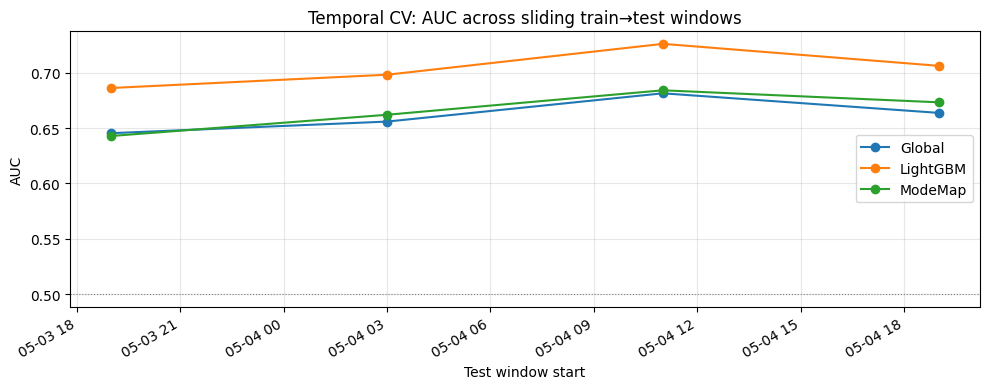

In [5]:
if folds:
    cv_factories = {n: factories[n] for n in ('Global', 'ModeMap', 'LightGBM')}
    cv_df = evaluate_models_on_folds(folds, cv_factories)
    summary = cv_df.groupby('model')[['auc', 'logloss', 'accuracy']].mean().round(4)
    print(summary)
    fig, ax = plt.subplots(figsize=(10, 4))
    cv_df['test_lo_dt'] = pd.to_datetime(cv_df['test_lo'], utc=True)
    for model, sub in cv_df.sort_values('test_lo_dt').groupby('model'):
        ax.plot(sub['test_lo_dt'], sub['auc'], '-o', label=model)
    ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8)
    ax.set_ylabel('AUC')
    ax.set_xlabel('Test window start')
    ax.set_title('Temporal CV: AUC across sliding train→test windows')
    ax.grid(alpha=0.3)
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
else:
    print('Not enough data for any temporal fold yet.')

## 4. Inference: scenario walkthrough

All three of the original questions answered from one trained model.

In [6]:
model = fitted['LightGBM']

mode = 'brawlBall'
mp = 'Backyard Bowl'

print(f'\n[1] Pre-draft tier list — {mode} on {mp}')
ranks = rank_brawlers_for_map(model, mode, mp, train_df=train, n_samples=80, seed=0)
for bid, p in ranks[:10]:
    print(f'  {names.get(bid, bid):20s}  P(win)={p:.3f}')


[1] Pre-draft tier list — brawlBall on Backyard Bowl
  DAMIAN                P(win)=0.853
  NAJIA                 P(win)=0.614
  LOLA                  P(win)=0.606
  OLLIE                 P(win)=0.595
  MINA                  P(win)=0.589
  GIGI                  P(win)=0.582
  GLOWBERT              P(win)=0.571
  SHADE                 P(win)=0.552
  COLETTE               P(win)=0.551
  TRUNK                 P(win)=0.538


In [7]:
print(f'\n[2] Mid-draft completion — A picked LOLA+GIGI, B picked JESSIE+EL PRIMO. Best 3rd pick for A?')
res = complete_team(
    model,
    my_team=(ids['LOLA'], ids['GIGI']),
    opp_team=(ids['JESSIE'], ids['EL PRIMO']),
    mode=mode, map=mp, top_k=8,
)
for bid, p in res:
    print(f'  {names.get(bid, bid):20s}  P(win)={p:.3f}')


[2] Mid-draft completion — A picked LOLA+GIGI, B picked JESSIE+EL PRIMO. Best 3rd pick for A?
  DAMIAN                P(win)=0.952
  NAJIA                 P(win)=0.863
  MINA                  P(win)=0.861
  GLOWBERT              P(win)=0.842
  OLLIE                 P(win)=0.842
  COLETTE               P(win)=0.840
  DRACO                 P(win)=0.830
  TRUNK                 P(win)=0.829


In [8]:
print(f'\n[3] Last pick — A picked LOLA+GIGI, B picked JESSIE+EL PRIMO+BIBI. Best 3rd for A?')
res = last_pick(
    model,
    my_partial_team=(ids['LOLA'], ids['GIGI']),
    opp_team=(ids['JESSIE'], ids['EL PRIMO'], ids['BIBI']),
    mode=mode, map=mp, top_k=8,
)
for bid, p in res:
    print(f'  {names.get(bid, bid):20s}  P(win)={p:.3f}')


[3] Last pick — A picked LOLA+GIGI, B picked JESSIE+EL PRIMO+BIBI. Best 3rd for A?
  DAMIAN                P(win)=0.951
  COLETTE               P(win)=0.870
  NAJIA                 P(win)=0.848
  MINA                  P(win)=0.834
  GLOWBERT              P(win)=0.829
  LUMI                  P(win)=0.826
  OLLIE                 P(win)=0.822
  DRACO                 P(win)=0.816


## 5. Sanity check: brawler usage and win rates

If the model is recommending brawler X with absurd confidence, this section explains why.
Often the answer is just "X has 65% raw win rate in 40k games" — that's not a model bug,
that's the meta. Worth keeping an eye on for release-meta inflation.

In [9]:
rows = []
for _, r in train.iterrows():
    for b in r['team_a']:
        rows.append((int(b), int(r['team_a_wins'])))
    for b in r['team_b']:
        rows.append((int(b), 1 - int(r['team_a_wins'])))
rank = pd.DataFrame(rows, columns=['brawler_id', 'win']).groupby('brawler_id').agg(n=('win', 'size'), wr=('win', 'mean'))
rank['name'] = rank.index.map(lambda b: names.get(b, str(b)))
rank = rank[rank['n'] >= 200].sort_values('wr', ascending=False)
rank.head(15).style.format({'wr': '{:.4f}'}).background_gradient(subset=['wr'], cmap='Greens')

,n,wr,name
brawler_id,,,
16000090,968,0.6488,OLLIE
16000104,33088,0.6453,DAMIAN
16000053,1424,0.6404,LOLA
16000101,1118,0.6333,GLOWBERT
16000100,1216,0.6135,GIGI
16000093,1008,0.6032,JAE-YONG
16000096,844,0.5948,TRUNK
16000087,1732,0.5935,JUJU
16000091,3484,0.5913,LUMI
